### Transient vs Steady State conductor temperature

This notebook illustrates the use of the TB 601 implementation included in the **Pypacity** library for studyinf both the thermal transient and steady-state behaviour of ACSR conductors.

---

**PyPacity**

Copyright (c) 2026 Group of Advanced Electro-Technologies (GTEA). Universidad de Cantabria. All rights reserved    
SPDX-License-Identifier: GPL-3.0-only

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

from pypacity.cigre601 import cigre601
from pypacity.cable import cable
from pypacity.case import case

import matplotlib.pyplot as plt 
import numpy as np

from test_utils_plots import get_subplots

In [2]:
data = {"air_temperature": [40, 32, 32, 38, 34],
        "current": [800, 800, 550, 950, 700],
        "solar_radiation": [400, 350, 250, 360, 300],
        "wind_direction": [60, 45, 40, 45, 45],
        "wind_speed": [0.6, 1.0, 1.0, 1.0, 1.5],
        "n_intervals":5}

In [3]:
# Steady state temperature calculation
NSELECT = 1

Cable = cable.Cable()
c_db, error = Cable.load_cable_db()
Cable.set_cable(1, conductor = 'DRAKE')
Cable.ABSORP = 0.8
Cable.EMISS  = 0.8

Case_ss = case.Case()
Case_ss.demo( NSELECT )

Case_ss.CDR_LAT_DEG = 30
Case_ss.CDR_ELEV = 0
Case_ss.ALBEDO = 0.1
Case_ss.Z1_DEG = 0
Case_ss.SOLAR  = 0
Case_ss.beta   = 0
n_intervals    = data['n_intervals']

Tss = []

for i in range(n_intervals):

    Case_ss.SolarRadiation = data['solar_radiation'][i]
    Case_ss.XIPRELOAD = data['current'][i]
    Case_ss.DWIND_DEG = data['wind_direction'][i]
    Case_ss.VWIND = data['wind_speed'][i]
    Case_ss.TAMB  = data['air_temperature'][i]

    TB601 = cigre601.CIGRE601()
    TB601.Debug = 0
    TB601.set_cable( Cable )
    TB601.set_case(  Case_ss )
    TB601.Debug = 0
    TB601.cigre601()
    # TB601.output()

    Tss.append( Case_ss.TCDRPRELOAD)


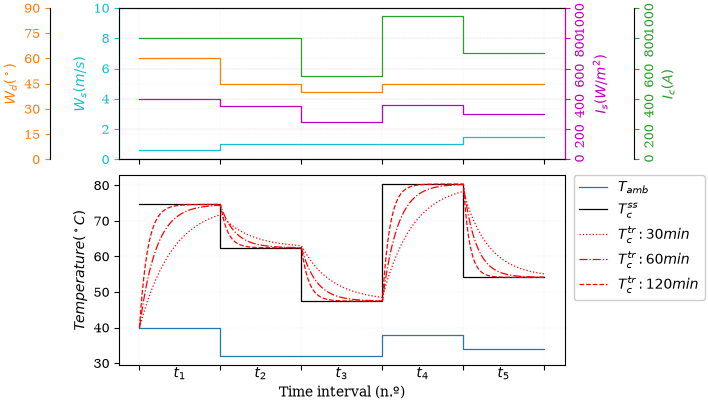

In [4]:
# Transient temperature calculation
NSELECT = 3

ax_main_arr = get_subplots(data, Tss, ar=1.75);
Tc0 = data['air_temperature'][0]

Cable = cable.Cable()
c_db, error = Cable.load_cable_db()
Cable.set_cable(1, conductor = 'DRAKE')
Cable.ABSORP = 0.8
Cable.EMISS  = 0.8

for TT, ls in zip([30,60,120],[':','-.','--']):
    Ttr  = []
    for ti in range(n_intervals):

        Case_tr = case.Case()
        Case_tr.demo( NSELECT )

        Case_tr.TTfromST  = 0     
        if len(Ttr)==0: Case_tr.TCDRinitial = Tc0
        else:          Case_tr.TCDRinitial = Ttr[-1]

        Case_tr.CDR_LAT_DEG = 30
        Case_tr.CDR_ELEV = 0
        Case_tr.ALBEDO = 0.1
        Case_tr.beta   = 0
        Case_tr.Z1_DEG = 0
        Case_tr.SOLAR = 0

        Case_tr.SolarRadiation = data['solar_radiation'][ti]
        Case_tr.TAMB           = data['air_temperature'][ti]
        Case_tr.DWIND_DEG      = data['wind_direction'][ti]
        Case_tr.VWIND          = data['wind_speed'][ti]

        Case_tr.XISTEP = data['current'][ti]

        Case_tr.SORM    = 1
        Case_tr.TT      = TT
        Case_tr.DELTIME = 10

        TB601 = cigre601.CIGRE601()
        TB601.Debug = 0
        TB601.set_cable( Cable )
        TB601.set_case(  Case_tr )
        TB601.Debug = 0
        TB601.cigre601()

        if ti==0: Ttr.extend(TB601.Case1.ATCDR)
        else:     Ttr.extend(TB601.Case1.ATCDR[1:])

    time = Case_tr.DELTIME*np.arange(len(Ttr))/(TT*60)

    ax_main_arr[1].plot(time,Ttr,'r',ls=ls, label=r'$T_c^{tr}$'+f'$:{TT} min$')
    


ax_main_arr[1].legend( bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,ncol=1)

plt.show()
plt.savefig(f"images/ss_vs_tran.pdf", dpi=300, bbox_inches='tight', pad_inches=0.05);
